<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/EstimationofLasso_True.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

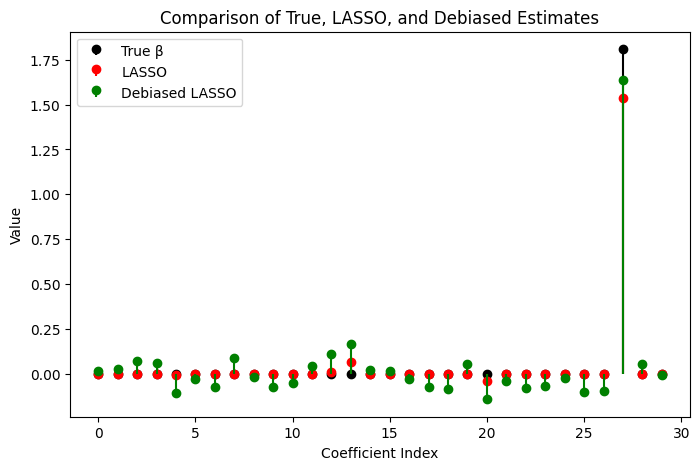

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
# Step 1: Generate high‐dimensional data (p > n)
np.random.seed(42)
n = 100
p = 300
X = np.random.randn(n, p)
beta_true = np.zeros(p)
nonzero_idx = np.random.choice(p, 10, replace=False)
beta_true[nonzero_idx] = np.random.uniform(1.5, 3.0, 10)
y = X @ beta_true + np.random.normal(0, 1, n)
# Step 2: Standardize predictors
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Step 3: Fit LASSO
lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X, y)
beta_lasso = lasso.coef_
# Step 4: Compute residuals
residuals = y - X@ beta_lasso
# Step 5: Approximate inverse covariance (simple diagonal approximation) Sigma_hat = (X.T @ X) / n
Sigma_hat = (X.T @ X) / n
M = np.diag(1 / np.diag(Sigma_hat))
# Step 6: Debiased estimator
beta_debiased = beta_lasso + (M @ X.T @ residuals) / n
# Step 7: Compare estimates
plt.figure(figsize=(8, 5))
plt.stem(beta_true[:30], linefmt='black', markerfmt='ko', basefmt=' ')
plt.stem(beta_lasso[:30], linefmt='red', markerfmt='ro', basefmt=' ')
plt.stem(beta_debiased[:30], linefmt='green', markerfmt='go', basefmt=' ')
plt.legend(["True β", "LASSO", "Debiased LASSO"])
plt.title("Comparison of True, LASSO, and Debiased Estimates")
plt.xlabel("Coefficient Index")
plt.ylabel("Value")
plt.show()